# English Premier League 2026/27 Match Outcome Prediction

### Multi-source EPL data | Referee tendencies | Linear Regression | XGBoost

**Goal:** predict EPL match outcomes (`H`, `D`, `A`) for upcoming 2026/27 fixtures.

This repository contains two prediction modes:

1. **Pre-match:** historical team strength, form, home/away performance and referee tendencies.
2. **In-match:** adds the current match state requested for the project — shots, shots on target, half-time score, corners, fouls, yellow cards, red cards and current xG when available.

> **Leakage rule:** the final score is used only as ground truth. `FullTimeHomeGoals` and `FullTimeAwayGoals` are never model inputs when predicting `FullTimeResult`.

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error,
    r2_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier
import joblib

BASE = Path.cwd()
if not (BASE / "data").exists() and (BASE.parent / "data").exists():
    BASE = BASE.parent

sys.path.insert(0, str(BASE / "src"))
from epl_pipeline import (
    merge_sources, build_features, compute_current_state, future_pre_row,
    PREMATCH_FEATURES, LIVE_EXTRA_FEATURES, CAT_FEATURES,
    LABEL_ORDER, LABEL_TO_INT
)

RAW = BASE / "data" / "raw"
DATA = BASE / "data"
RESULTS = BASE / "results"
MODELS = BASE / "models"

print("Repository:", BASE)

Repository: /mnt/data/epl_2026_27_match_prediction


## 1. Load and integrate the three datasets

The match key is:

`Season + Date + normalized Home Team + normalized Away Team`

This reconciles:

- the original EPL history,
- the referee/statistics dataset,
- the referee/xG workbook.

The merge also restores missing 2024/25 matches and adds the 2025/26 fixture/result rows supplied in `Book1.xlsx`.

In [2]:

# Fast/reproducible default: load the already reconciled project table.
combined = pd.read_csv(DATA / "epl_combined.csv", parse_dates=["MatchDate"])

print("Combined rows:", len(combined))
print("Completed rows:", combined["FullTimeResult"].notna().sum())
print("Unplayed rows:", combined["FullTimeResult"].isna().sum())

# Optional full rebuild from the three raw sources:
# combined = merge_sources(
#     RAW / "epl_final.csv",
#     RAW / "epl-allseasons-matchstats.csv",
#     RAW / "Book1.xlsx"
# )
# combined.to_csv(DATA / "epl_combined.csv", index=False)


Combined rows: 9937
Completed rows: 9726
Unplayed rows: 211


In [3]:
season_audit = (
    combined.groupby("Season")
    .agg(
        Rows=("MatchKey", "size"),
        Completed=("FullTimeResult", lambda s: s.notna().sum()),
        RefereeKnown=("Referee", lambda s: s.notna().sum()),
        xGKnown=("xG_Home", lambda s: s.notna().sum())
    )
    .reset_index()
)
display(season_audit)

,Season,Rows,Completed,RefereeKnown,xGKnown
0,2000/01,380,380,0,0
1,2001/02,380,380,0,0
2,2002/03,380,380,0,0
3,2003/04,335,335,0,0
4,2004/05,335,335,0,0
5,2005/06,380,380,0,0
6,2006/07,380,380,0,0
7,2007/08,380,380,0,0
8,2008/09,380,380,0,0
9,2009/10,380,380,0,0


### Reproducibility note

The repository stores `epl_combined.csv` and `engineered_features.csv` so the main notebook opens and runs quickly on GitHub/Colab. The raw-source merge and full feature-engineering functions remain in `src/epl_pipeline.py`, and the commented rebuild cells can regenerate those files from the three supplied datasets.

## 2. Referee impact analysis

Referee features are treated as **historical tendencies/associations**, not causal effects.

Examples:

- Average total fouls
- Average total yellow cards
- Average total red cards
- Home vs away yellow-card bias
- Historical H/D/A rates

A referee's current-match cards are not used as a pre-match feature; the model uses historical referee behavior. The in-match model can additionally use cards already given in the current match.

In [4]:
ref_profile = pd.read_csv(DATA / "referee_impact_profile.csv")
ref_eligible = pd.read_csv(RESULTS / "referee_impact_eligible_20_matches.csv")

display(
    ref_eligible.head(15)[[
        "Referee","Matches","Avg_Total_Fouls","Avg_Total_Yellow",
        "Avg_Total_Red","Home_Yellow_Bias","Home_Win_Rate","Draw_Rate","Away_Win_Rate"
    ]]
)

,Referee,Matches,Avg_Total_Fouls,Avg_Total_Yellow,Avg_Total_Red,Home_Yellow_Bias,Home_Win_Rate,Draw_Rate,Away_Win_Rate
0,John Brooks,53,22.320755,4.509434,0.075472,0.207547,0.490566,0.264151,0.245283
1,Tim Robinson,34,23.647059,4.470588,0.058824,-0.529412,0.500000,0.264706,0.235294
2,David Coote,40,23.800000,4.325000,0.150000,-0.275000,0.475000,0.225000,0.300000
3,Darren Bond,22,21.818182,4.227273,0.181818,-0.681818,0.545455,0.272727,0.181818
4,Darren England,46,22.260870,4.195652,0.130435,-0.891304,0.456522,0.239130,0.304348
5,Craig Pawson,60,22.983333,4.166667,0.116667,-0.300000,0.383333,0.216667,0.400000
6,Robert Jones,67,23.462687,4.164179,0.134328,-0.820896,0.492537,0.238806,0.268657
7,Peter Bankes,52,21.557692,4.153846,0.076923,-0.461538,0.557692,0.230769,0.211538
8,Simon Hooper,77,20.896104,4.077922,0.077922,-0.467532,0.519481,0.246753,0.233766
9,Chris Kavanagh,55,21.309091,3.927273,0.163636,-0.181818,0.345455,0.309091,0.345455


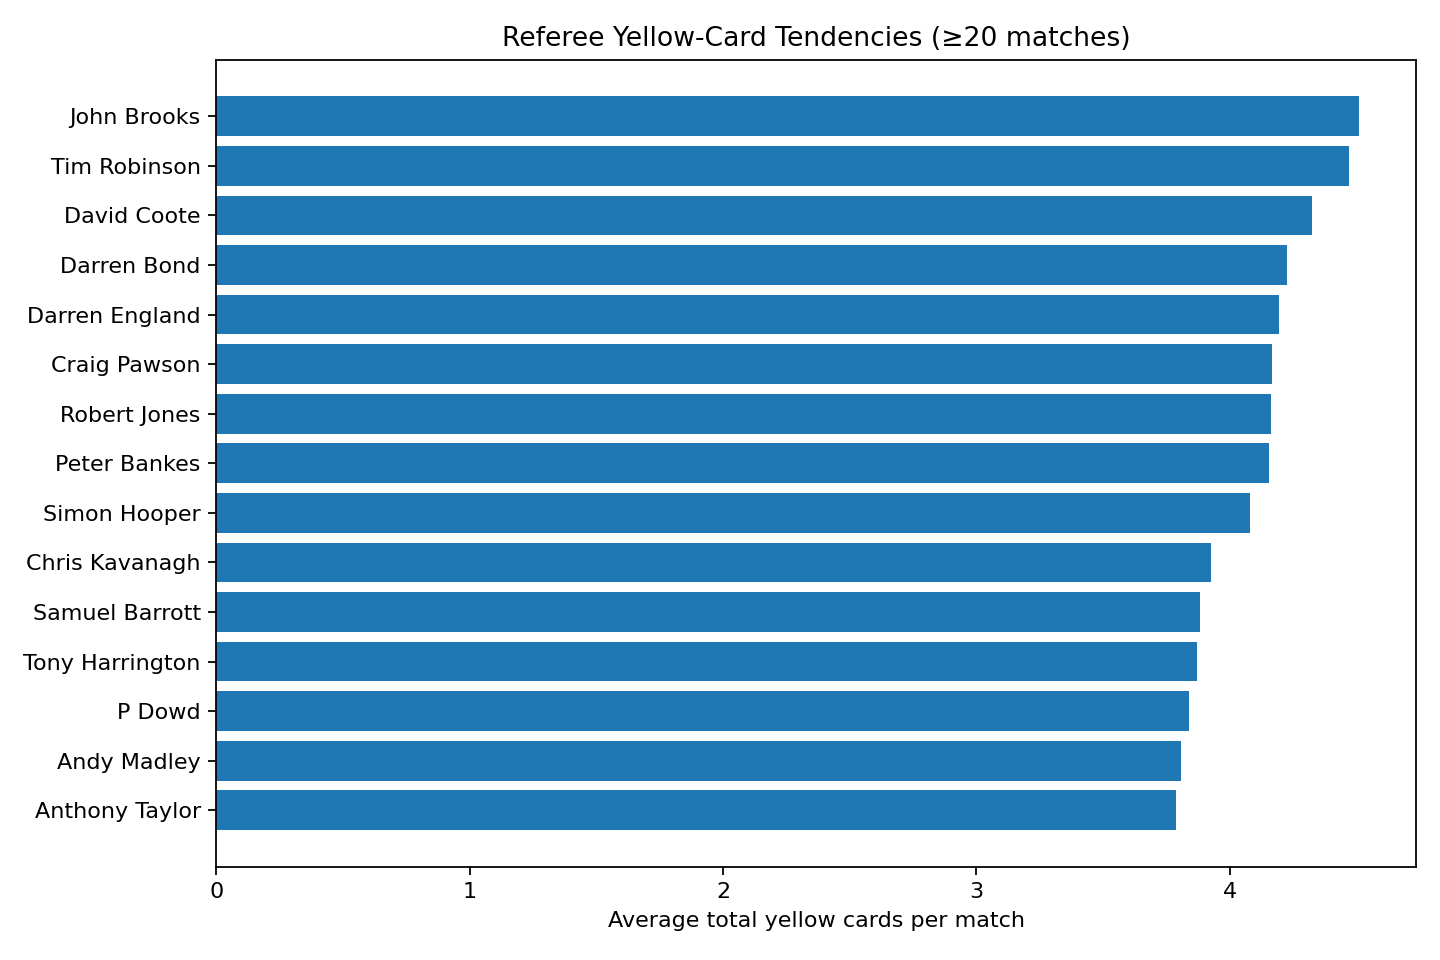

In [5]:
display(Image(filename=str(RESULTS / "referee_yellow_cards.png"), width=700))

## 3. Build chronological features

For every match, the following historical variables are calculated **before** updating team/referee state:

- Elo rating
- last-5 and last-10 points per game
- recent win rate
- recent goals for/against
- home/away recent performance
- previous shots, SOT, corners and discipline
- referee history

Current-match statistics are then engineered separately.

In [6]:

# Fast/reproducible default: load engineered features created by the integration pipeline.
features = pd.read_csv(DATA / "engineered_features.csv", parse_dates=["MatchDate"])
completed = features[features["FullTimeResult"].notna()].copy()
completed["SeasonYear"] = completed["Season"].astype(str).str[:4].astype(int)

print("Engineered shape:", features.shape)
print("Completed rows:", len(completed))

# To rebuild features from the raw data instead:
# features = build_features(combined)
# features.to_csv(DATA / "engineered_features.csv", index=False)


Engineered shape: (9828, 99)
Completed rows: 9617


## 4. Model feature groups

### Pre-match

Uses only historical information.

### In-match

Adds:

- `HalfTimeHomeGoals`, `HalfTimeAwayGoals`
- `HomeShots`, `AwayShots`
- `HomeShotsOnTarget`, `AwayShotsOnTarget`
- `HomeCorners`, `AwayCorners`
- `HomeFouls`, `AwayFouls`
- `HomeYellowCards`, `AwayYellowCards`
- `HomeRedCards`, `AwayRedCards`
- current xG when available

`FullTimeHomeGoals` and `FullTimeAwayGoals` remain ground truth.

In [7]:
print("Pre-match feature count:", len(PREMATCH_FEATURES))
print("In-match extra feature count:", len(LIVE_EXTRA_FEATURES))

print("\nExample pre-match features:")
print(PREMATCH_FEATURES[:15])

print("\nExample requested in-match features:")
print(LIVE_EXTRA_FEATURES[:21])

Pre-match feature count: 49
In-match extra feature count: 32

Example pre-match features:
['HomeTeam', 'AwayTeam', 'Referee', 'Home_Elo', 'Away_Elo', 'Elo_Difference', 'Home_PPG_Last5', 'Away_PPG_Last5', 'Home_PPG_Last10', 'Away_PPG_Last10', 'Home_WinRate_Last5', 'Away_WinRate_Last5', 'Home_GoalsFor_Last5', 'Away_GoalsFor_Last5', 'Home_GoalsAgainst_Last5']

Example requested in-match features:
['HalfTimeHomeGoals', 'HalfTimeAwayGoals', 'HT_GoalDifference', 'HomeShots', 'AwayShots', 'Shots_Difference', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'SOT_Difference', 'HomeCorners', 'AwayCorners', 'Corners_Difference', 'HomeFouls', 'AwayFouls', 'Fouls_Difference', 'HomeYellowCards', 'AwayYellowCards', 'Yellow_Difference', 'HomeRedCards', 'AwayRedCards', 'Red_Difference']


## 5. Chronological train/test split

The held-out test season is **2024/25**.

This is intentionally not a random split: sports prediction should respect time ordering.

In [8]:
train_pre = completed[completed["SeasonYear"] < 2024].copy()
test_pre = completed[completed["SeasonYear"] == 2024].copy()

# All requested live features except current xG are required.
# xG is optional because older seasons do not contain it.
required_live = [
    c for c in LIVE_EXTRA_FEATURES
    if c not in ["xG_Home", "xG_Away", "xG_Difference"]
]
live_complete = completed[completed[required_live].notna().all(axis=1)].copy()
live_train = live_complete[live_complete["SeasonYear"] < 2024].copy()
live_test = live_complete[live_complete["SeasonYear"] == 2024].copy()

print("Pre-match train/test:", len(train_pre), len(test_pre))
print("In-match train/test:", len(live_train), len(live_test))

Pre-match train/test: 9068 380
In-match train/test: 9030 350


In [9]:
def make_preprocessor(cat_cols, num_cols, scale=False, impute=False):
    num_transform = []
    if impute:
        num_transform.append(("imputer", SimpleImputer(strategy="median")))
    if scale:
        num_transform.append(("scaler", StandardScaler()))

    num_pipe = "passthrough" if not num_transform else Pipeline(num_transform)

    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", num_pipe, num_cols)
    ])

def clean_frame(data, columns):
    x = data[columns].copy()
    for c in columns:
        if c not in CAT_FEATURES:
            x[c] = pd.to_numeric(x[c], errors="coerce")
    return x

params_pre = dict(
    n_estimators=250, max_depth=2, learning_rate=0.05,
    min_child_weight=1, subsample=0.90, colsample_bytree=0.90,
    reg_alpha=0.0, reg_lambda=1.0
)

params_live = dict(
    n_estimators=350, max_depth=4, learning_rate=0.035,
    min_child_weight=3, subsample=0.85, colsample_bytree=0.90,
    reg_alpha=0.2, reg_lambda=1.5
)

## 6. Linear Regression baseline

Linear Regression estimates final goal difference:

`Home Goals - Away Goals`

That continuous prediction is converted into:

- positive → Home Win
- negative → Away Win
- near zero → Draw

This provides an interpretable baseline against the nonlinear XGBoost model.

In [10]:
num_pre = [c for c in PREMATCH_FEATURES if c not in CAT_FEATURES]
num_live = [c for c in PREMATCH_FEATURES + LIVE_EXTRA_FEATURES if c not in CAT_FEATURES]

lr_pre = Pipeline([
    ("prep", make_preprocessor(CAT_FEATURES, num_pre, scale=True, impute=True)),
    ("model", LinearRegression())
])
lr_pre.fit(clean_frame(train_pre, PREMATCH_FEATURES), train_pre["GoalDifference"])
lr_pre_gd = lr_pre.predict(clean_frame(test_pre, PREMATCH_FEATURES))
lr_pre_result = np.where(lr_pre_gd > 0.25, "H", np.where(lr_pre_gd < -0.25, "A", "D"))

print("Pre-match LR accuracy:", accuracy_score(test_pre["FullTimeResult"], lr_pre_result))
print("Pre-match LR Macro F1:", f1_score(test_pre["FullTimeResult"], lr_pre_result, average="macro"))

Pre-match LR accuracy: 0.4868421052631579
Pre-match LR Macro F1: 0.44077266818214617


## 7. XGBoost pre-match model

In [11]:
pp = make_preprocessor(CAT_FEATURES, num_pre, scale=False, impute=False)
Xtr = pp.fit_transform(clean_frame(train_pre, PREMATCH_FEATURES))
Xte = pp.transform(clean_frame(test_pre, PREMATCH_FEATURES))

xgb_pre = XGBClassifier(
    objective="multi:softprob", num_class=3, eval_metric="mlogloss",
    random_state=42, n_jobs=-1, **params_pre
)
xgb_pre.fit(Xtr, train_pre["FullTimeResult"].map(LABEL_TO_INT), verbose=False)

xgb_pre_pred = np.array(LABEL_ORDER)[xgb_pre.predict(Xte).astype(int)]

print("Pre-match XGBoost accuracy:", accuracy_score(test_pre["FullTimeResult"], xgb_pre_pred))
print("Pre-match XGBoost Macro F1:", f1_score(test_pre["FullTimeResult"], xgb_pre_pred, average="macro"))
print(classification_report(
    test_pre["FullTimeResult"], xgb_pre_pred, labels=LABEL_ORDER, zero_division=0
))

Pre-match XGBoost accuracy: 0.5263157894736842
Pre-match XGBoost Macro F1: 0.3983521575529834
              precision    recall  f1-score   support

           A       0.56      0.52      0.54       132
           D       1.00      0.01      0.02        93
           H       0.51      0.84      0.63       155

    accuracy                           0.53       380
   macro avg       0.69      0.46      0.40       380
weighted avg       0.65      0.53      0.45       380



## 8. In-match Linear Regression + XGBoost

This is where the user's requested current-match variables enter the model.

At halftime, for example, the model can see the current shots, half-time score, corners and cards and estimate the eventual result.

In [12]:
lr_live = Pipeline([
    ("prep", make_preprocessor(CAT_FEATURES, num_live, scale=True, impute=True)),
    ("model", LinearRegression())
])
lr_live.fit(clean_frame(live_train, PREMATCH_FEATURES + LIVE_EXTRA_FEATURES), live_train["GoalDifference"])
lr_live_gd = lr_live.predict(clean_frame(live_test, PREMATCH_FEATURES + LIVE_EXTRA_FEATURES))
lr_live_result = np.where(lr_live_gd > 0.25, "H", np.where(lr_live_gd < -0.25, "A", "D"))

lp = make_preprocessor(CAT_FEATURES, num_live, scale=False, impute=False)
XLtr = lp.fit_transform(clean_frame(live_train, PREMATCH_FEATURES + LIVE_EXTRA_FEATURES))
XLte = lp.transform(clean_frame(live_test, PREMATCH_FEATURES + LIVE_EXTRA_FEATURES))

xgb_live = XGBClassifier(
    objective="multi:softprob", num_class=3, eval_metric="mlogloss",
    random_state=42, n_jobs=-1, **params_live
)
xgb_live.fit(XLtr, live_train["FullTimeResult"].map(LABEL_TO_INT), verbose=False)
xgb_live_pred = np.array(LABEL_ORDER)[xgb_live.predict(XLte).astype(int)]

print("In-match LR accuracy:", accuracy_score(live_test["FullTimeResult"], lr_live_result))
print("In-match XGBoost accuracy:", accuracy_score(live_test["FullTimeResult"], xgb_live_pred))
print("In-match XGBoost Macro F1:", f1_score(live_test["FullTimeResult"], xgb_live_pred, average="macro"))

In-match LR accuracy: 0.6571428571428571
In-match XGBoost accuracy: 0.64
In-match XGBoost Macro F1: 0.5630637477422703


In [13]:
metrics = pd.DataFrame([
    ["Linear Regression — Pre-match",
     accuracy_score(test_pre.FullTimeResult, lr_pre_result),
     f1_score(test_pre.FullTimeResult, lr_pre_result, average="macro"),
     mean_absolute_error(test_pre.GoalDifference, lr_pre_gd),
     np.sqrt(mean_squared_error(test_pre.GoalDifference, lr_pre_gd)),
     r2_score(test_pre.GoalDifference, lr_pre_gd)],
    ["XGBoost — Pre-match",
     accuracy_score(test_pre.FullTimeResult, xgb_pre_pred),
     f1_score(test_pre.FullTimeResult, xgb_pre_pred, average="macro"),
     np.nan,np.nan,np.nan],
    ["Linear Regression — In-match",
     accuracy_score(live_test.FullTimeResult, lr_live_result),
     f1_score(live_test.FullTimeResult, lr_live_result, average="macro"),
     mean_absolute_error(live_test.GoalDifference, lr_live_gd),
     np.sqrt(mean_squared_error(live_test.GoalDifference, lr_live_gd)),
     r2_score(live_test.GoalDifference, lr_live_gd)],
    ["XGBoost — In-match",
     accuracy_score(live_test.FullTimeResult, xgb_live_pred),
     f1_score(live_test.FullTimeResult, xgb_live_pred, average="macro"),
     np.nan,np.nan,np.nan]
], columns=["Model","Accuracy","Macro_F1","MAE","RMSE","R2"])

display(metrics)
metrics.to_csv(RESULTS/"model_metrics_2024_25_reproduced.csv", index=False)

,Model,Accuracy,Macro_F1,MAE,RMSE,R2
0,Linear Regression — Pre-match,0.486842,0.440773,1.418767,1.777540,0.090250
1,XGBoost — Pre-match,0.526316,0.398352,NaN,NaN,NaN
2,Linear Regression — In-match,0.657143,0.589241,0.920641,1.162634,0.619655
3,XGBoost — In-match,0.640000,0.563064,NaN,NaN,NaN


## 9. Confusion matrices and feature importance

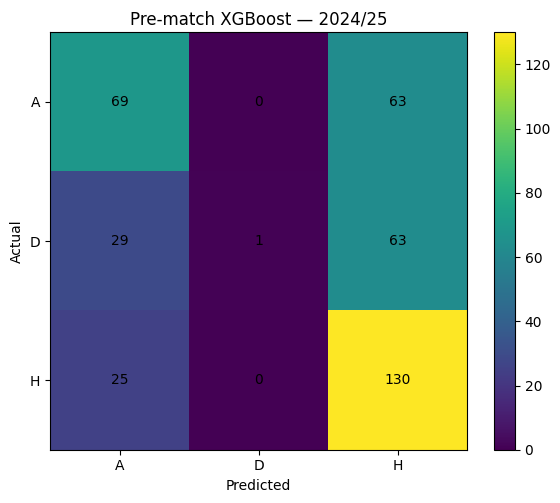

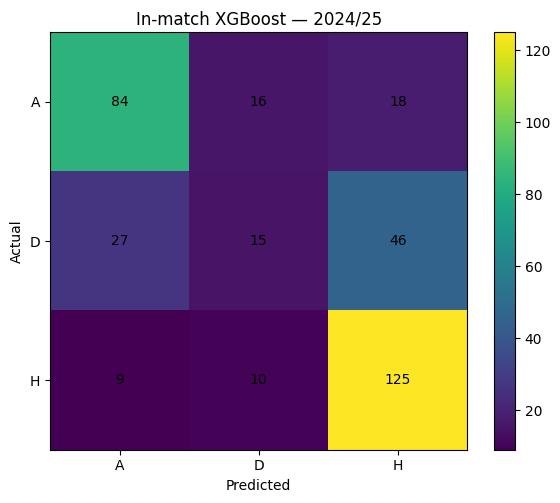

In [14]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, interpolation="nearest")
    fig.colorbar(im, ax=ax)
    ax.set(
        xticks=range(3), yticks=range(3),
        xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
        xlabel="Predicted", ylabel="Actual", title=title
    )
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

plot_confusion(test_pre.FullTimeResult, xgb_pre_pred, "Pre-match XGBoost — 2024/25")
plot_confusion(live_test.FullTimeResult, xgb_live_pred, "In-match XGBoost — 2024/25")

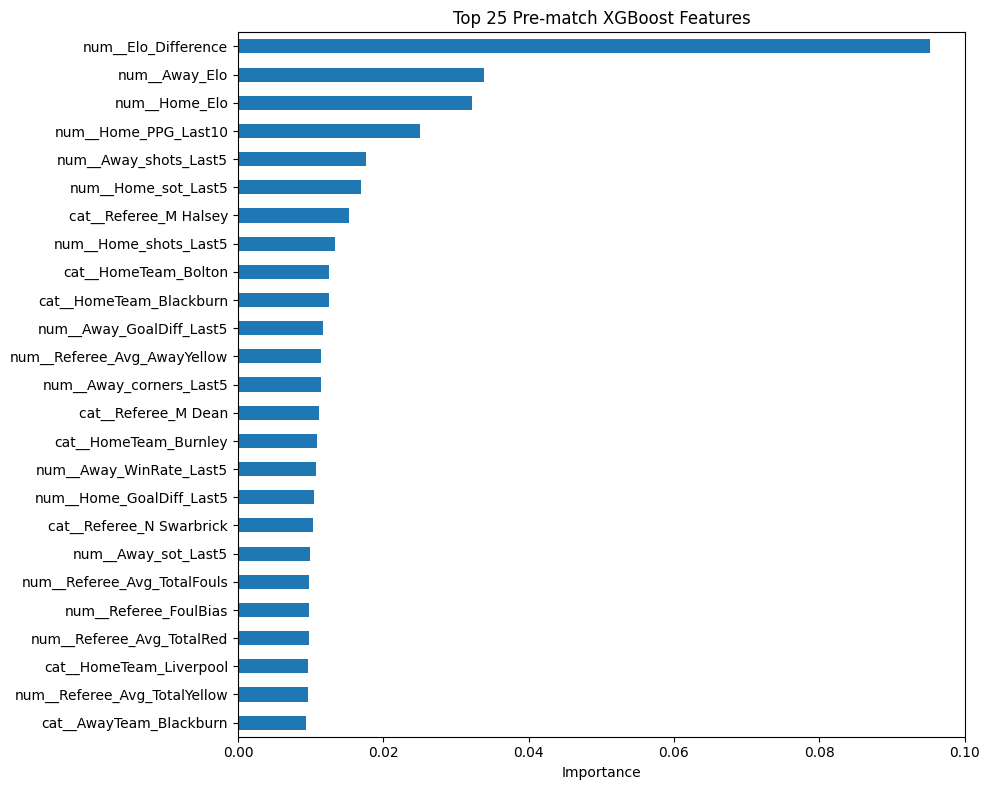

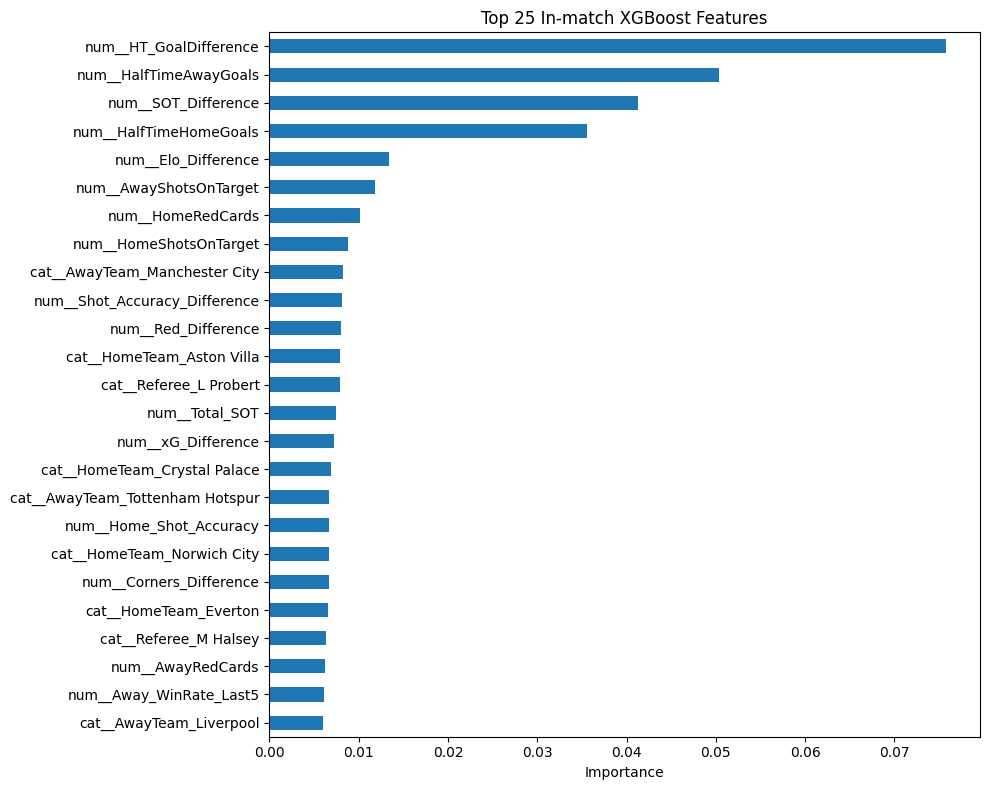

In [15]:
def feature_importance_table(model, preprocessor, top_n=25):
    return (
        pd.Series(model.feature_importances_, index=preprocessor.get_feature_names_out())
        .sort_values(ascending=False)
        .head(top_n)
        .sort_values()
    )

pre_imp = feature_importance_table(xgb_pre, pp)
live_imp = feature_importance_table(xgb_live, lp)

fig, ax = plt.subplots(figsize=(10,8))
pre_imp.plot(kind="barh", ax=ax)
ax.set_title("Top 25 Pre-match XGBoost Features")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10,8))
live_imp.plot(kind="barh", ax=ax)
ax.set_title("Top 25 In-match XGBoost Features")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 10. Train final production models

The final pre-match model is trained on every completed match in the integrated history, including the completed portion of 2025/26.

The final in-match model is trained on every row containing the requested live match statistics. xG is optional.

In [16]:
final_pp = make_preprocessor(CAT_FEATURES, num_pre, scale=False, impute=False)
final_pp.fit(clean_frame(completed, PREMATCH_FEATURES))
final_pre_model = XGBClassifier(
    objective="multi:softprob", num_class=3, eval_metric="mlogloss",
    random_state=42, n_jobs=-1, **params_pre
)
final_pre_model.fit(
    final_pp.transform(clean_frame(completed, PREMATCH_FEATURES)),
    completed["FullTimeResult"].map(LABEL_TO_INT),
    verbose=False
)

final_lr = Pipeline([
    ("prep", make_preprocessor(CAT_FEATURES, num_pre, scale=True, impute=True)),
    ("model", LinearRegression())
])
final_lr.fit(clean_frame(completed, PREMATCH_FEATURES), completed["GoalDifference"])

final_live_pp = make_preprocessor(CAT_FEATURES, num_live, scale=False, impute=False)
final_live_pp.fit(clean_frame(live_complete, PREMATCH_FEATURES + LIVE_EXTRA_FEATURES))
final_live_model = XGBClassifier(
    objective="multi:softprob", num_class=3, eval_metric="mlogloss",
    random_state=42, n_jobs=-1, **params_live
)
final_live_model.fit(
    final_live_pp.transform(clean_frame(live_complete, PREMATCH_FEATURES + LIVE_EXTRA_FEATURES)),
    live_complete["FullTimeResult"].map(LABEL_TO_INT),
    verbose=False
)

final_live_lr = Pipeline([
    ("prep", make_preprocessor(CAT_FEATURES, num_live, scale=True, impute=True)),
    ("model", LinearRegression())
])
final_live_lr.fit(clean_frame(live_complete, PREMATCH_FEATURES + LIVE_EXTRA_FEATURES), live_complete["GoalDifference"])

joblib.dump(
    {"preprocessor":final_pp,"model":final_pre_model,"label_order":LABEL_ORDER,"features":PREMATCH_FEATURES},
    MODELS/"prematch_xgboost.joblib"
)
joblib.dump(final_lr, MODELS/"prematch_linear_regression.joblib")
joblib.dump(
    {"preprocessor":final_live_pp,"model":final_live_model,"label_order":LABEL_ORDER,
     "features":PREMATCH_FEATURES + LIVE_EXTRA_FEATURES},
    MODELS/"inmatch_xgboost.joblib"
)
joblib.dump(final_live_lr, MODELS/"inmatch_linear_regression.joblib")

print("Final models saved.")

Final models saved.


## 11. Predict upcoming 2026/27 fixtures

The local fixture snapshot contains the next fixture window used for this repository build.

The predictions are **pre-match** predictions. Since referee assignments are not present in the fixture snapshot, `Referee="Unknown"` is used; later, a confirmed referee can be inserted and the prediction regenerated.

In [17]:
fixtures = pd.read_csv(DATA/"2026_27_upcoming_fixtures_mw6_mw10.csv", parse_dates=["Date"])

# Recompute the post-history state used for future predictions.
teams, refs, league_foul, league_yellow = compute_current_state(completed)

future_rows=[]
for _, r in fixtures.iterrows():
    row = future_pre_row(
        r["HomeTeam"], r["AwayTeam"], r["Date"],
        teams, refs, league_foul, league_yellow,
        referee="Unknown"
    )
    p = final_pre_model.predict_proba(final_pp.transform(row))[0]
    future_rows.append({
        "Matchweek": int(r["Matchweek"]),
        "Date": r["Date"].date().isoformat(),
        "KickoffLocal": r["KickoffLocal"],
        "HomeTeam": r["HomeTeam"],
        "AwayTeam": r["AwayTeam"],
        "Referee": "Unknown",
        "HomeWin_Probability": float(p[2]),
        "Draw_Probability": float(p[1]),
        "AwayWin_Probability": float(p[0]),
        "Prediction": LABEL_ORDER[int(np.argmax(p))],
        "Confidence": float(np.max(p))
    })

upcoming_pred = pd.DataFrame(future_rows)
upcoming_pred.to_csv(RESULTS/"2026_27_upcoming_predictions_mw6_mw10.csv", index=False)

display(upcoming_pred.head(20))

,Matchweek,Date,KickoffLocal,HomeTeam,AwayTeam,Referee,HomeWin_Probability,Draw_Probability,AwayWin_Probability,Prediction,Confidence
0,6,2026-10-10,12:30,Arsenal,Leeds United,Unknown,0.806540,0.100913,0.092547,H,0.806540
1,6,2026-10-10,15:00,Ipswich Town,Fulham,Unknown,0.218454,0.246262,0.535284,A,0.535284
2,6,2026-10-10,15:00,Chelsea,AFC Bournemouth,Unknown,0.630574,0.204377,0.165049,H,0.630574
3,6,2026-10-10,15:00,Aston Villa,Brentford,Unknown,0.655013,0.185945,0.159042,H,0.655013
4,6,2026-10-10,15:00,Sunderland,Brighton & Hove Albion,Unknown,0.307431,0.216627,0.475941,A,0.475941
5,6,2026-10-10,17:30,Manchester United,Tottenham Hotspur,Unknown,0.550115,0.204708,0.245176,H,0.550115
6,6,2026-10-11,14:00,Crystal Palace,Nottingham Forest,Unknown,0.561052,0.225258,0.213690,H,0.561052
7,6,2026-10-11,14:00,Hull City,Everton,Unknown,0.254473,0.253408,0.492119,A,0.492119
8,6,2026-10-11,16:30,Liverpool,Manchester City,Unknown,0.484083,0.264254,0.251663,H,0.484083
9,6,2026-10-12,20:00,Coventry City,Newcastle United,Unknown,0.219442,0.224409,0.556149,A,0.556149


## 12. In-match Arsenal vs Chelsea prediction function

This demonstrates the feature set requested for the original project.

Supply the state of the actual match at prediction time — for example at half-time.

**Do not supply the final score.**

In [18]:
def predict_in_match(
    home_team, away_team,
    ht_home, ht_away,
    home_shots, away_shots,
    home_sot, away_sot,
    home_corners, away_corners,
    home_fouls, away_fouls,
    home_yellow, away_yellow,
    home_red, away_red,
    home_xg=np.nan, away_xg=np.nan,
    referee="Unknown", match_date=None
):
    date = pd.Timestamp(match_date) if match_date is not None else pd.Timestamp.today()

    row = future_pre_row(
        home_team, away_team, date,
        teams, refs, league_foul, league_yellow,
        referee=referee
    ).iloc[0].to_dict()

    row.update({
        "HalfTimeHomeGoals": ht_home,
        "HalfTimeAwayGoals": ht_away,
        "HT_GoalDifference": ht_home - ht_away,

        "HomeShots": home_shots,
        "AwayShots": away_shots,
        "Shots_Difference": home_shots - away_shots,

        "HomeShotsOnTarget": home_sot,
        "AwayShotsOnTarget": away_sot,
        "SOT_Difference": home_sot - away_sot,

        "HomeCorners": home_corners,
        "AwayCorners": away_corners,
        "Corners_Difference": home_corners - away_corners,

        "HomeFouls": home_fouls,
        "AwayFouls": away_fouls,
        "Fouls_Difference": home_fouls - away_fouls,

        "HomeYellowCards": home_yellow,
        "AwayYellowCards": away_yellow,
        "Yellow_Difference": home_yellow - away_yellow,

        "HomeRedCards": home_red,
        "AwayRedCards": away_red,
        "Red_Difference": home_red - away_red,

        "xG_Home": home_xg,
        "xG_Away": away_xg,
        "xG_Difference": (
            home_xg - away_xg
            if pd.notna(home_xg) and pd.notna(away_xg)
            else np.nan
        ),

        "Home_Shot_Accuracy": home_sot / max(home_shots, 1),
        "Away_Shot_Accuracy": away_sot / max(away_shots, 1),
        "Shot_Accuracy_Difference": (
            home_sot / max(home_shots, 1) -
            away_sot / max(away_shots, 1)
        ),

        "Total_Shots": home_shots + away_shots,
        "Total_SOT": home_sot + away_sot,
        "Total_Corners": home_corners + away_corners,
        "Total_Fouls": home_fouls + away_fouls,
        "Total_Cards": home_yellow + away_yellow + home_red + away_red
    })

    X = pd.DataFrame([row])[PREMATCH_FEATURES + LIVE_EXTRA_FEATURES]
    probs = final_live_model.predict_proba(final_live_pp.transform(X))[0]

    return pd.DataFrame([{
        "HomeTeam": home_team,
        "AwayTeam": away_team,
        "HomeWin_Probability": float(probs[2]),
        "Draw_Probability": float(probs[1]),
        "AwayWin_Probability": float(probs[0]),
        "Prediction": LABEL_ORDER[int(np.argmax(probs))]
    }])

example = predict_in_match(
    "Arsenal", "Chelsea",
    ht_home=1, ht_away=0,
    home_shots=8, away_shots=4,
    home_sot=4, away_sot=2,
    home_corners=5, away_corners=2,
    home_fouls=6, away_fouls=8,
    home_yellow=1, away_yellow=2,
    home_red=0, away_red=0,
    home_xg=1.05, away_xg=0.42,
    referee="Unknown",
    match_date="2026-10-04"
)

display(example)
example.to_csv(RESULTS/"example_inmatch_arsenal_vs_chelsea.csv", index=False)

,HomeTeam,AwayTeam,HomeWin_Probability,Draw_Probability,AwayWin_Probability,Prediction
0,Arsenal,Chelsea,0.828404,0.133355,0.038241,H


## 13. Project conclusion

The completed system now supports both:

**Upcoming-match forecasting**
→ uses historical team and referee information.

**In-match forecasting**
→ adds live shots, half-time score, corners, fouls and cards.

The strongest methodological point is that the model never receives the final score when predicting the final result, avoiding direct target leakage.

### Recommended next production upgrade

Refresh the historical dataset with current 2026/27 completed results before every new prediction window. Once the referee assignment is known, insert the referee before generating the pre-match probabilities.